# PF epithelial trajectory and spatial pseudotime

This notebook reproduces the data-driven results in UniGeneX manuscript **Figure 4A and Figure 4D**. It connects the epithelial single-cell atlas trajectory to the pulmonary-fibrosis Xenium query in two stages:

- **Figure 4A:** reconstruct the epithelial atlas diffusion map and project spatial cells into its DC2/DC3 coordinates using the newly rerun 30-neighbor query-to-atlas mapping;
- **Figure 4D:** calculate the AT1-to–Aberrant Basaloid atlas pseudotime and transfer it to spatial cells using the newly rerun 300-neighbor mapping.

The notebook saves the transferred values as a compact table for the subsequent histology notebook. Figure 4E is intentionally kept separate because it requires loading a 2.8 GB registered H&E image.

## Position in the PF workflow

By default, this notebook reads two compact query-by-atlas connectivity matrices generated by `transformer_map_to_epithelial_atlas.sh`. For an interactive alternative, set `RUN_MAPPING = True` below; the optional cell uses the same public `AtlasMapper` implementation to create the files:

1. 30 neighbors, matching the spatial projection in Figure 4A;
2. 300 neighbors, matching the smoother pseudotime transfer in Figure 4D.

Each matrix contains UMAP fuzzy connectivity weights between query cells (rows) and atlas cells (columns). The original analysis stored these weights inside a much larger combined AnnData graph. The rerun stores only the cross-dataset block needed below, reducing disk and memory use without changing the projection formulas.

## Data contract and outputs

Download and extract the modular archives from the [UniGeneX PF Zenodo record](https://doi.org/10.5281/zenodo.22489310). Set `UNIGENEX_DATA_DIR` to the extracted data directory containing `PF/`. If it is unset, the notebook looks for `./data/PF` relative to the working directory. Required files are:

| Input | Role |
|---|---|
| `PF/sp_map_to_sc_Epi/UGE_atlas_sub.h5ad` | Epithelial atlas metadata, expression, and neighbor graph |
| `PF/sp_map_to_sc_Epi/UGE_sp_sub.h5ad` | Spatial UGE query used only when `RUN_MAPPING = True` |
| `PF/selected_index/diffmap_index_all.npy` | Atlas cells used to reconstruct the diffusion map |
| `PF/selected_index/diffmap_index.npy` | Atlas cells displayed as the Figure 4A trajectory |
| `PF/selected_index/diffmap_index_AT1_to_AB.npy` | AT1-to–Aberrant Basaloid pseudotime path |
| `PF/sp_map_to_sc_Epi/figure4_rerun_results/knn30/query_to_atlas_mapping.h5ad` | Figure 4A mapping |
| `PF/sp_map_to_sc_Epi/figure4_rerun_results/knn300/query_to_atlas_mapping.h5ad` | Figure 4D mapping |

Figures and compact tables are written to `outputs/04_epithelial_trajectory_and_spatial_pseudotime/` by default. Set `UNIGENEX_OUTPUT_DIR` to choose another output directory. No input `.h5ad` file is modified or overwritten.

The mapping shell script creates only the `knn30` and `knn300` mapping files. This notebook subsequently calculates spatial pseudotime and writes `spatial_pseudotime.csv.gz`; that compact table is the input passed to notebook 05.

## Key parameters

Two mappings of the same epithelial query serve different downstream purposes. Both use the public `AtlasMapper`; only the number of neighbors differs.

| Parameter | Manuscript value | Meaning |
|---|---:|---|
| `RUN_MAPPING` | `False` | Load the two saved mappings. Set to `True` to regenerate them interactively. |
| `n_neighbors` for Figure 4A | `30` | Preserves local atlas structure for trajectory projection. |
| `n_neighbors` for Figure 4D | `300` | Provides a smoother weighted transfer of atlas pseudotime. |
| `keep_unlabeled_atlas` | `True` | Retains all atlas cells in the mapping geometry; cells without `ct_anno` do not vote for labels. |
| `recompute_pca` | `True` | Fits the epithelial reference PCA and matching nearest-neighbor index. |
| `TRAJECTORY_MASS_CUTOFF` | `4.0` | Keeps query cells with sufficient connectivity to the curated epithelial trajectory. |
| selected-index files | released manuscript subsets | Define the diffusion-map population, displayed trajectory, and AT1-to–Aberrant Basaloid path. |

The 30- and 300-neighbor results are not interchangeable. The selected-index files and trajectory-mass cutoff are manuscript-reproduction settings rather than general UniGeneX defaults.

In [1]:
from pathlib import Path
from importlib.metadata import version
import copy
import gc
import os
import platform
import sys
import warnings

import anndata as ad
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
import scanpy as sc
from scipy import sparse
from scipy.sparse import issparse, linalg, spdiags

DATA_ROOT = Path(
    os.environ.get("UNIGENEX_DATA_DIR", Path.cwd() / "data")
).expanduser().resolve()
PF_DIR = DATA_ROOT / "PF"
EPITHELIAL_DIR = PF_DIR / "sp_map_to_sc_Epi"
INDEX_DIR = PF_DIR / "selected_index"
ATLAS_PATH = EPITHELIAL_DIR / "UGE_atlas_sub.h5ad"
QUERY_PATH = EPITHELIAL_DIR / "UGE_sp_sub.h5ad"
MAPPING_ROOT = EPITHELIAL_DIR / "figure4_rerun_results"
MAPPING_30_PATH = (
    MAPPING_ROOT / "knn30"
    / "query_to_atlas_mapping.h5ad"
)
MAPPING_300_PATH = (
    MAPPING_ROOT / "knn300"
    / "query_to_atlas_mapping.h5ad"
)
DIFFMAP_ALL_PATH = INDEX_DIR / "diffmap_index_all.npy"
DIFFMAP_DISPLAY_PATH = INDEX_DIR / "diffmap_index.npy"
PSEUDOTIME_PATH = INDEX_DIR / "diffmap_index_AT1_to_AB.npy"

OUTPUT_DIR = Path(
    os.environ.get(
        "UNIGENEX_OUTPUT_DIR",
        Path.cwd() / "outputs"
        / "04_epithelial_trajectory_and_spatial_pseudotime",
    )
).expanduser().resolve()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SPATIAL_PSEUDOTIME_OUTPUT = OUTPUT_DIR / "spatial_pseudotime.csv.gz"

# Full mappings are best run from the shell. Change this only for an
# interactive mapping run in the notebook.
RUN_MAPPING = False
ATLAS_LABEL_COLUMN = "ct_anno"
LABEL_COLUMN = f"predict_mapped_{ATLAS_LABEL_COLUMN}"
PROBABILITY_COLUMN = f"{LABEL_COLUMN}_prob"
FIGURE4A_COLOR_COLUMN = "pred_atlas"
TRAJECTORY_MASS_CUTOFF = 4.0
TRAJECTORY_CELL_TYPES = [
    "SCGB1A1+/SCGB3A1+/SCGB3A2+",
    "SCGB3A1+/SCGB3A2+",
    "AT2",
    "AT1",
    "Aberrant Basaloid",
]
# Locate the local UniGeneX package from the repository root or a nested
# notebook directory such as docs/vignettes/PF.
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "UniGeneX" / "mapping.py").is_file():
        VALIDATION_ROOT = candidate
        break
else:
    raise FileNotFoundError("Could not locate the UniGeneX package.")
if str(VALIDATION_ROOT) not in sys.path:
    sys.path.insert(0, str(VALIDATION_ROOT))

from UniGeneX.mapping import (
    AtlasMapper,
    load_mapping_result,
    project_query_to_atlas,
)

CELL_TYPE_COLORS = {
    "SCGB1A1+/SCGB3A1+/SCGB3A2+": "#c2ffed",
    "SCGB3A1+/SCGB3A2+": "#a079bf",
    "AT2": "#1ce6ff",
    "AT1": "#ffff00",
    "Aberrant Basaloid": "#ff34ff",
    "Basal": "#ffdbe5",
}

required_files = [
    ATLAS_PATH, DIFFMAP_ALL_PATH, DIFFMAP_DISPLAY_PATH, PSEUDOTIME_PATH,
]
if RUN_MAPPING:
    required_files.append(QUERY_PATH)
else:
    required_files.extend([MAPPING_30_PATH, MAPPING_300_PATH])
missing_files = [path for path in required_files if not path.is_file()]
if missing_files:
    formatted = "\n".join(f"  - {path}" for path in missing_files)
    raise FileNotFoundError(
        "Missing Figure 4A/4D inputs:\n" + formatted + "\n"
        "Set UNIGENEX_DATA_DIR to the directory containing PF/. "
        "With RUN_MAPPING=False, run "
        "transformer_map_to_epithelial_atlas.sh first."
    )

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"Data root: {DATA_ROOT}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Notebook 05 handoff: {SPATIAL_PSEUDOTIME_OUTPUT}")
print(f"Mapping mode: {'run in notebook' if RUN_MAPPING else 'load saved results'}")
print(
    f"Python {platform.python_version()}, "
    f"anndata {version('anndata')}, scanpy {version('scanpy')}"
)

Data root: /path/to/zenodo/extraction
Output directory: UniGeneX/Real_data_PF/outputs/04_epithelial_trajectory_and_spatial_pseudotime
Mapping mode: load saved results
Python 3.10.20, anndata 0.11.4, scanpy 1.11.5


## Generate the mappings (optional)

For the full spatial dataset, the recommended reproducible route is the script launcher. First edit `DATA_ROOT` in `Real_data_PF/transformer_map_to_epithelial_atlas.sh`, then run:

```bash
bash Real_data_PF/transformer_map_to_epithelial_atlas.sh
```

It uses the same `AtlasMapper.fit(...).map(...)` workflow shown below and writes separate 30- and 300-neighbor results. Keeping `RUN_MAPPING = False` skips this potentially long step and loads the saved mappings. Set it to `True` only when you want to regenerate both mappings interactively.

In [2]:
if RUN_MAPPING:
    query = ad.read_h5ad(QUERY_PATH)
    for n_neighbors, output_path in [
        (30, MAPPING_30_PATH),
        (300, MAPPING_300_PATH),
    ]:
        atlas = ad.read_h5ad(ATLAS_PATH)
        mapper = AtlasMapper(
            atlas,
            ATLAS_LABEL_COLUMN,
            n_neighbors=n_neighbors,
            keep_unlabeled_atlas=True,
        ).fit(recompute_pca=True)
        mapping = mapper.map(query)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        mapper.save_index(output_path.parent)
        mapping.write_h5ad(output_path)
        print(f"Saved {n_neighbors}-neighbor mapping: {output_path}")

    del atlas, mapper, mapping, query
else:
    print(
        "Using precomputed mappings from "
        "transformer_map_to_epithelial_atlas.sh."
    )

Using precomputed mappings from transformer_map_to_epithelial_atlas.sh.


## Reconstruct the epithelial atlas diffusion map

The manuscript trajectory was calculated from the atlas neighbor graph, not from the spatial query. We load the atlas in backed mode and materialize only observation metadata plus the two sparse neighbor matrices. The 1,741-gene expression matrix is not needed for this step.

`diffmap_index_all.npy` defines the broad epithelial population used to estimate the diffusion components. The two smaller index files are subsequently interpreted as named subsets of that same coordinate system. This preserves the original analysis logic while avoiding positional assumptions.

In [3]:
diffmap_index_all = np.load(DIFFMAP_ALL_PATH, allow_pickle=True).astype(str)
diffmap_index = np.load(DIFFMAP_DISPLAY_PATH, allow_pickle=True).astype(str)
pseudotime_index = np.load(PSEUDOTIME_PATH, allow_pickle=True).astype(str)

for name, values in {
    "diffmap_index_all": diffmap_index_all,
    "diffmap_index": diffmap_index,
    "diffmap_index_AT1_to_AB": pseudotime_index,
}.items():
    if pd.Index(values).has_duplicates:
        raise ValueError(f"{name} contains duplicated atlas cell names.")

atlas_backed = ad.read_h5ad(ATLAS_PATH, backed="r")
atlas_names = atlas_backed.obs_names.copy()
all_positions = atlas_names.get_indexer(diffmap_index_all)
if np.any(all_positions < 0):
    missing = diffmap_index_all[all_positions < 0]
    atlas_backed.file.close()
    raise KeyError(
        f"{len(missing):,} diffusion-map cells are absent from the atlas."
    )

atlas_obs = atlas_backed.obs.iloc[all_positions].copy()
atlas_connectivities = (
    atlas_backed.obsp["connectivities"][all_positions][:, all_positions]
    .tocsr().copy()
)
atlas_distances = (
    atlas_backed.obsp["distances"][all_positions][:, all_positions]
    .tocsr().copy()
)
neighbors_metadata = copy.deepcopy(atlas_backed.uns["neighbors"])
atlas_backed.file.close()

trajectory_atlas = ad.AnnData(
    X=sparse.csr_matrix((len(atlas_obs), 1), dtype=np.float32),
    obs=atlas_obs,
    var=pd.DataFrame(index=["unused_expression_placeholder"]),
)
trajectory_atlas.obsp["connectivities"] = atlas_connectivities
trajectory_atlas.obsp["distances"] = atlas_distances
trajectory_atlas.uns["neighbors"] = neighbors_metadata

missing_display = pd.Index(diffmap_index).difference(trajectory_atlas.obs_names)
missing_pt = pd.Index(pseudotime_index).difference(trajectory_atlas.obs_names)
if len(missing_display) or len(missing_pt):
    raise KeyError(
        "A selected trajectory index is not contained in diffmap_index_all: "
        f"display={len(missing_display)}, pseudotime={len(missing_pt)}."
    )

isolated_atlas_cells = int(
    (np.asarray(atlas_connectivities.sum(axis=1)).ravel() == 0).sum()
)
if isolated_atlas_cells:
    print(
        f"Note: {isolated_atlas_cells:,} selected atlas cells have no edge "
        "within this subset; Scanpy retains them when reproducing the "
        "historical subset diffusion map."
    )
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore", message="divide by zero encountered in divide",
        category=RuntimeWarning,
    )
    sc.tl.diffmap(trajectory_atlas, n_comps=30)
figure4a_atlas = trajectory_atlas[diffmap_index].copy()
pseudotime_atlas = trajectory_atlas[pseudotime_index].copy()

print(f"Diffusion-map population: {trajectory_atlas.n_obs:,} atlas cells")
print(f"Figure 4A displayed trajectory: {figure4a_atlas.n_obs:,} atlas cells")
print(f"AT1-to-AB pseudotime path: {pseudotime_atlas.n_obs:,} atlas cells")

Note: 3 selected atlas cells have no edge within this subset; Scanpy retains them when reproducing the historical subset diffusion map.


Diffusion-map population: 133,708 atlas cells
Figure 4A displayed trajectory: 72,076 atlas cells
AT1-to-AB pseudotime path: 20,830 atlas cells


## Figure 4A — atlas epithelial trajectory

The first panel shows the selected epithelial states in the reconstructed atlas DC2/DC3 space. Cell-type order, colors, and marker sizes follow the original PF plotting notebook. The larger diffusion-map population above was used to estimate the coordinates; only the manuscript trajectory subset is displayed here.

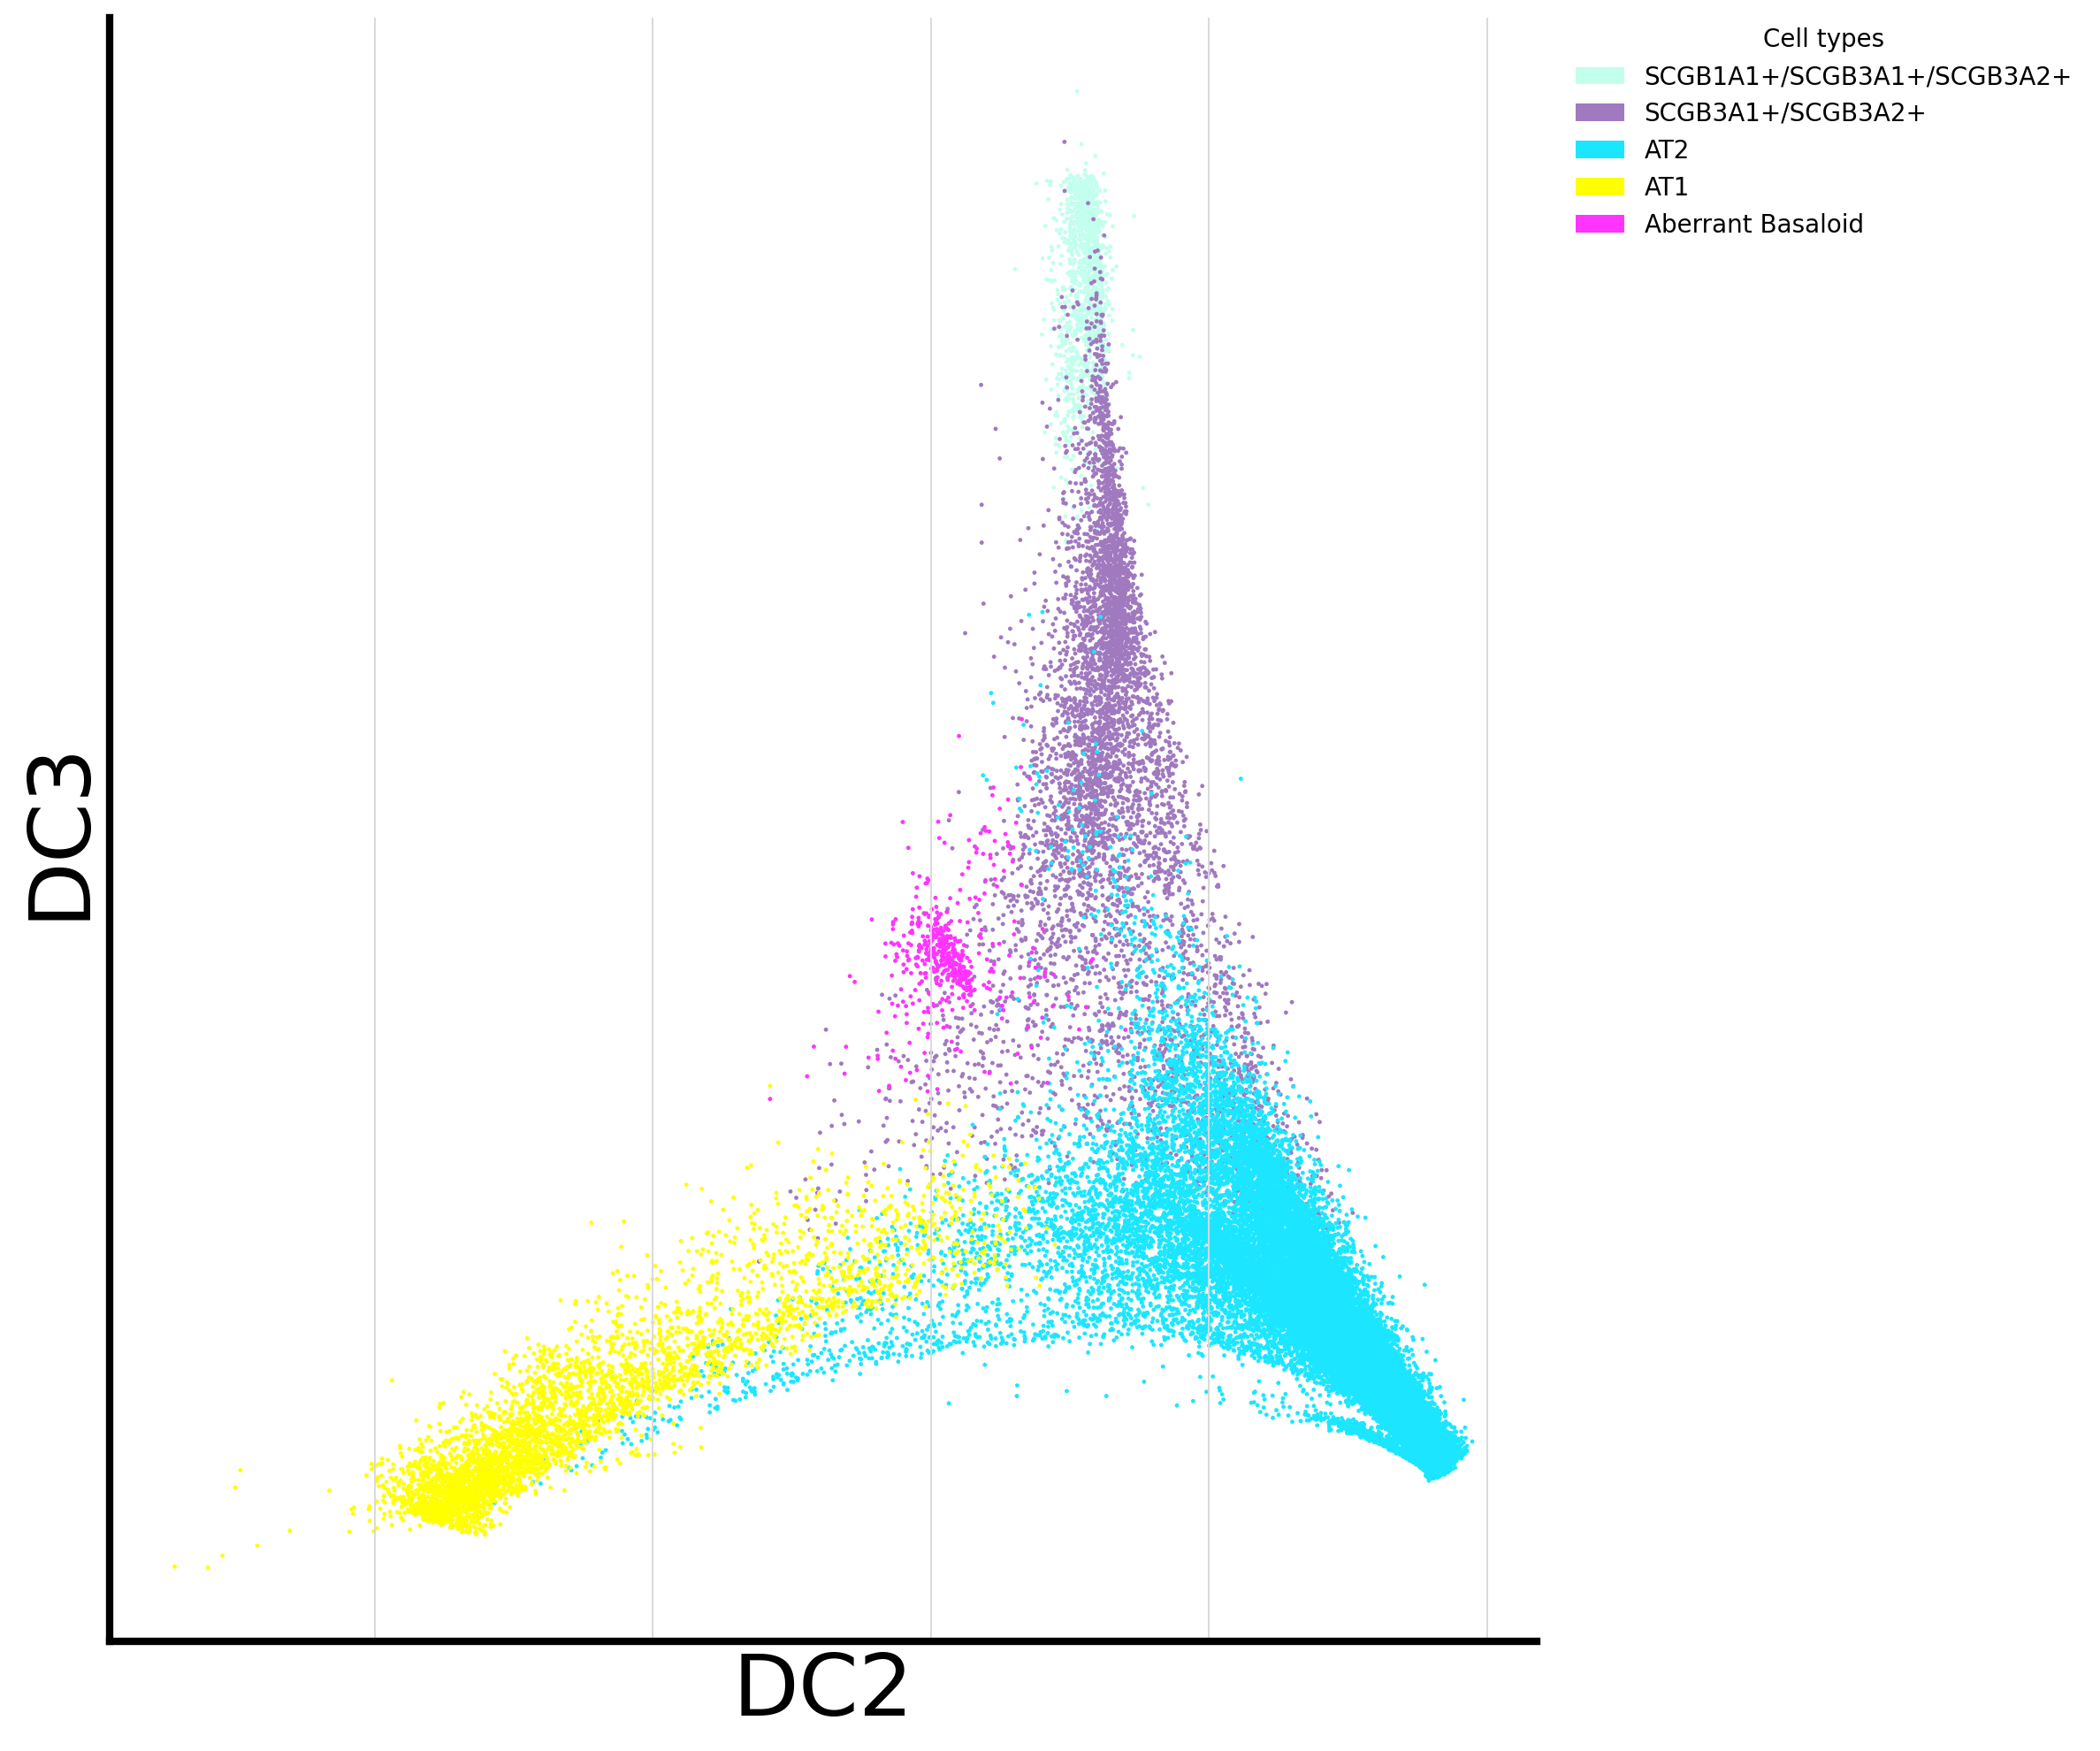

In [4]:
def style_diffmap_axis(ax, label_size=35, spine_width=3):
    ax.grid(True, color="#d9d9d9", linewidth=0.7)
    ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
    ax.set_yticks([])
    ax.set_xlabel("DC2", fontsize=label_size)
    ax.set_ylabel("DC3", fontsize=label_size)
    for spine in ["left", "bottom"]:
        ax.spines[spine].set_color("black")
        ax.spines[spine].set_linewidth(spine_width)

atlas_dc23 = figure4a_atlas.obsm["X_diffmap"][:, [1, 2]]
fig, ax = plt.subplots(figsize=(12, 10), dpi=200)
for cell_type in TRAJECTORY_CELL_TYPES:
    selected = figure4a_atlas.obs["ct_anno"].astype(str).eq(cell_type).to_numpy()
    ax.scatter(
        atlas_dc23[selected, 0], atlas_dc23[selected, 1],
        c=CELL_TYPE_COLORS[cell_type], s=3, marker="o",
        alpha=1.0, edgecolors="none", rasterized=True,
    )
style_diffmap_axis(ax)
legend_handles = [
    Patch(facecolor=CELL_TYPE_COLORS[name], label=name)
    for name in TRAJECTORY_CELL_TYPES
]
ax.legend(
    handles=legend_handles, title="Cell types", frameon=False,
    bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0,
)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "Figure4A_atlas_epithelial_trajectory.png",
    dpi=300, bbox_inches="tight", pad_inches=0.15,
)
plt.show()
plt.close(fig)

## Figure 4A — project the spatial query onto the atlas trajectory

For each query cell, the 30-neighbor mapping gives fuzzy connectivity weights to atlas cells. As in the original analysis, we:

1. normalize each row over the full mapped atlas reference;
2. restrict the projection to displayed trajectory cells with a non-missing `ct_anno`, matching `sl_sc_index` in the manuscript source notebook;
3. retain query cells whose **unnormalized** connectivity mass to that labeled trajectory subset is greater than 4.

The complete displayed trajectory remains visible as the gray atlas background, including cells without `ct_anno`; those unlabeled cells are excluded only from projection and thresholding. The mass threshold measures support for the labeled epithelial trajectory and is distinct from the majority-vote cell-type probability. Following the manuscript source notebook exactly, spatial cells are colored with the historical `pred_atlas` annotation retained in the query metadata. The new `predict_mapped_ct_anno` and its voting probability remain available in the exported table for comparison.

In [5]:
def prepare_query_metadata(mapping, path):
    """Check PF-specific metadata and create stable query identifiers."""
    parameters = dict(mapping.uns.get("mapping_parameters", {}))
    if not bool(parameters.get("keep_unlabeled_atlas", False)):
        raise ValueError(
            f"{path} was not generated with --keep-unlabeled-atlas. "
            "Rerun transformer_map_to_epithelial_atlas.sh to reproduce "
            "the historical complete-atlas mapping."
        )
    required_obs = {
        "sample", "cell_id", "x_centroid", "y_centroid",
        FIGURE4A_COLOR_COLUMN, LABEL_COLUMN, PROBABILITY_COLUMN,
    }
    missing_obs = required_obs.difference(mapping.obs.columns)
    if missing_obs:
        raise KeyError(f"{path} is missing columns: {sorted(missing_obs)}")

    if not np.array_equal(mapping.var_names, atlas_names):
        raise ValueError(
            f"{path} atlas columns do not exactly match the complete "
            "atlas observation order."
        )

    obs = mapping.obs.copy()
    obs["query_id"] = (
        obs["sample"].astype(str) + "::" + obs["cell_id"].astype(str)
    )
    if obs["query_id"].duplicated().any():
        raise ValueError(f"Query identifiers are not unique in {path}.")
    return obs, parameters


figure4a_projection_mask = (
    figure4a_atlas.obs["ct_anno"].notna().to_numpy()
)
figure4a_projection_atlas = figure4a_atlas[
    figure4a_projection_mask
].copy()

with warnings.catch_warnings():
    # Raw Xenium barcodes repeat between samples; query_id below is unique.
    warnings.filterwarnings(
        "ignore", message="Observation names are not unique.*",
        category=UserWarning,
    )
    mapping30 = load_mapping_result(MAPPING_30_PATH, expected_neighbors=30)
query30_obs, parameters30 = prepare_query_metadata(
    mapping30, MAPPING_30_PATH
)
figure4a_values = pd.DataFrame(
    figure4a_projection_atlas.obsm["X_diffmap"],
    index=figure4a_projection_atlas.obs_names,
)
projected30, trajectory_mass30 = project_query_to_atlas(
    mapping30, figure4a_values, normalize_by="all"
)
certain30 = trajectory_mass30 > TRAJECTORY_MASS_CUTOFF

figure4a_query = query30_obs.loc[certain30, [
    "query_id", "sample", "cell_id", "x_centroid", "y_centroid",
    FIGURE4A_COLOR_COLUMN, LABEL_COLUMN, PROBABILITY_COLUMN,
]].copy()
figure4a_query["trajectory_connectivity_mass"] = trajectory_mass30[certain30]
figure4a_query["projected_DC2"] = projected30[certain30, 1]
figure4a_query["projected_DC3"] = projected30[certain30, 2]
figure4a_query.to_csv(
    OUTPUT_DIR / "Figure4A_mapped_spatial_cells.csv.gz", index=False
)

print(
    f"Labeled Figure 4A projection atlas: "
    f"{figure4a_projection_atlas.n_obs:,} cells"
)
print(f"30-neighbor query cells: {len(query30_obs):,}")
print(
    f"Cells with trajectory connectivity mass > {TRAJECTORY_MASS_CUTOFF:g}: "
    f"{certain30.sum():,} ({certain30.mean():.1%})"
)
display(
    figure4a_query[FIGURE4A_COLOR_COLUMN]
    .value_counts().rename("n_cells").to_frame()
)

Labeled Figure 4A projection atlas: 61,692 cells
30-neighbor query cells: 128,353
Cells with trajectory connectivity mass > 4: 47,905 (37.3%)


,n_cells
pred_atlas,
AT2,26108
SCGB3A1+/SCGB3A2+,18394
AT1,2577
Aberrant Basaloid,822
Basal,4


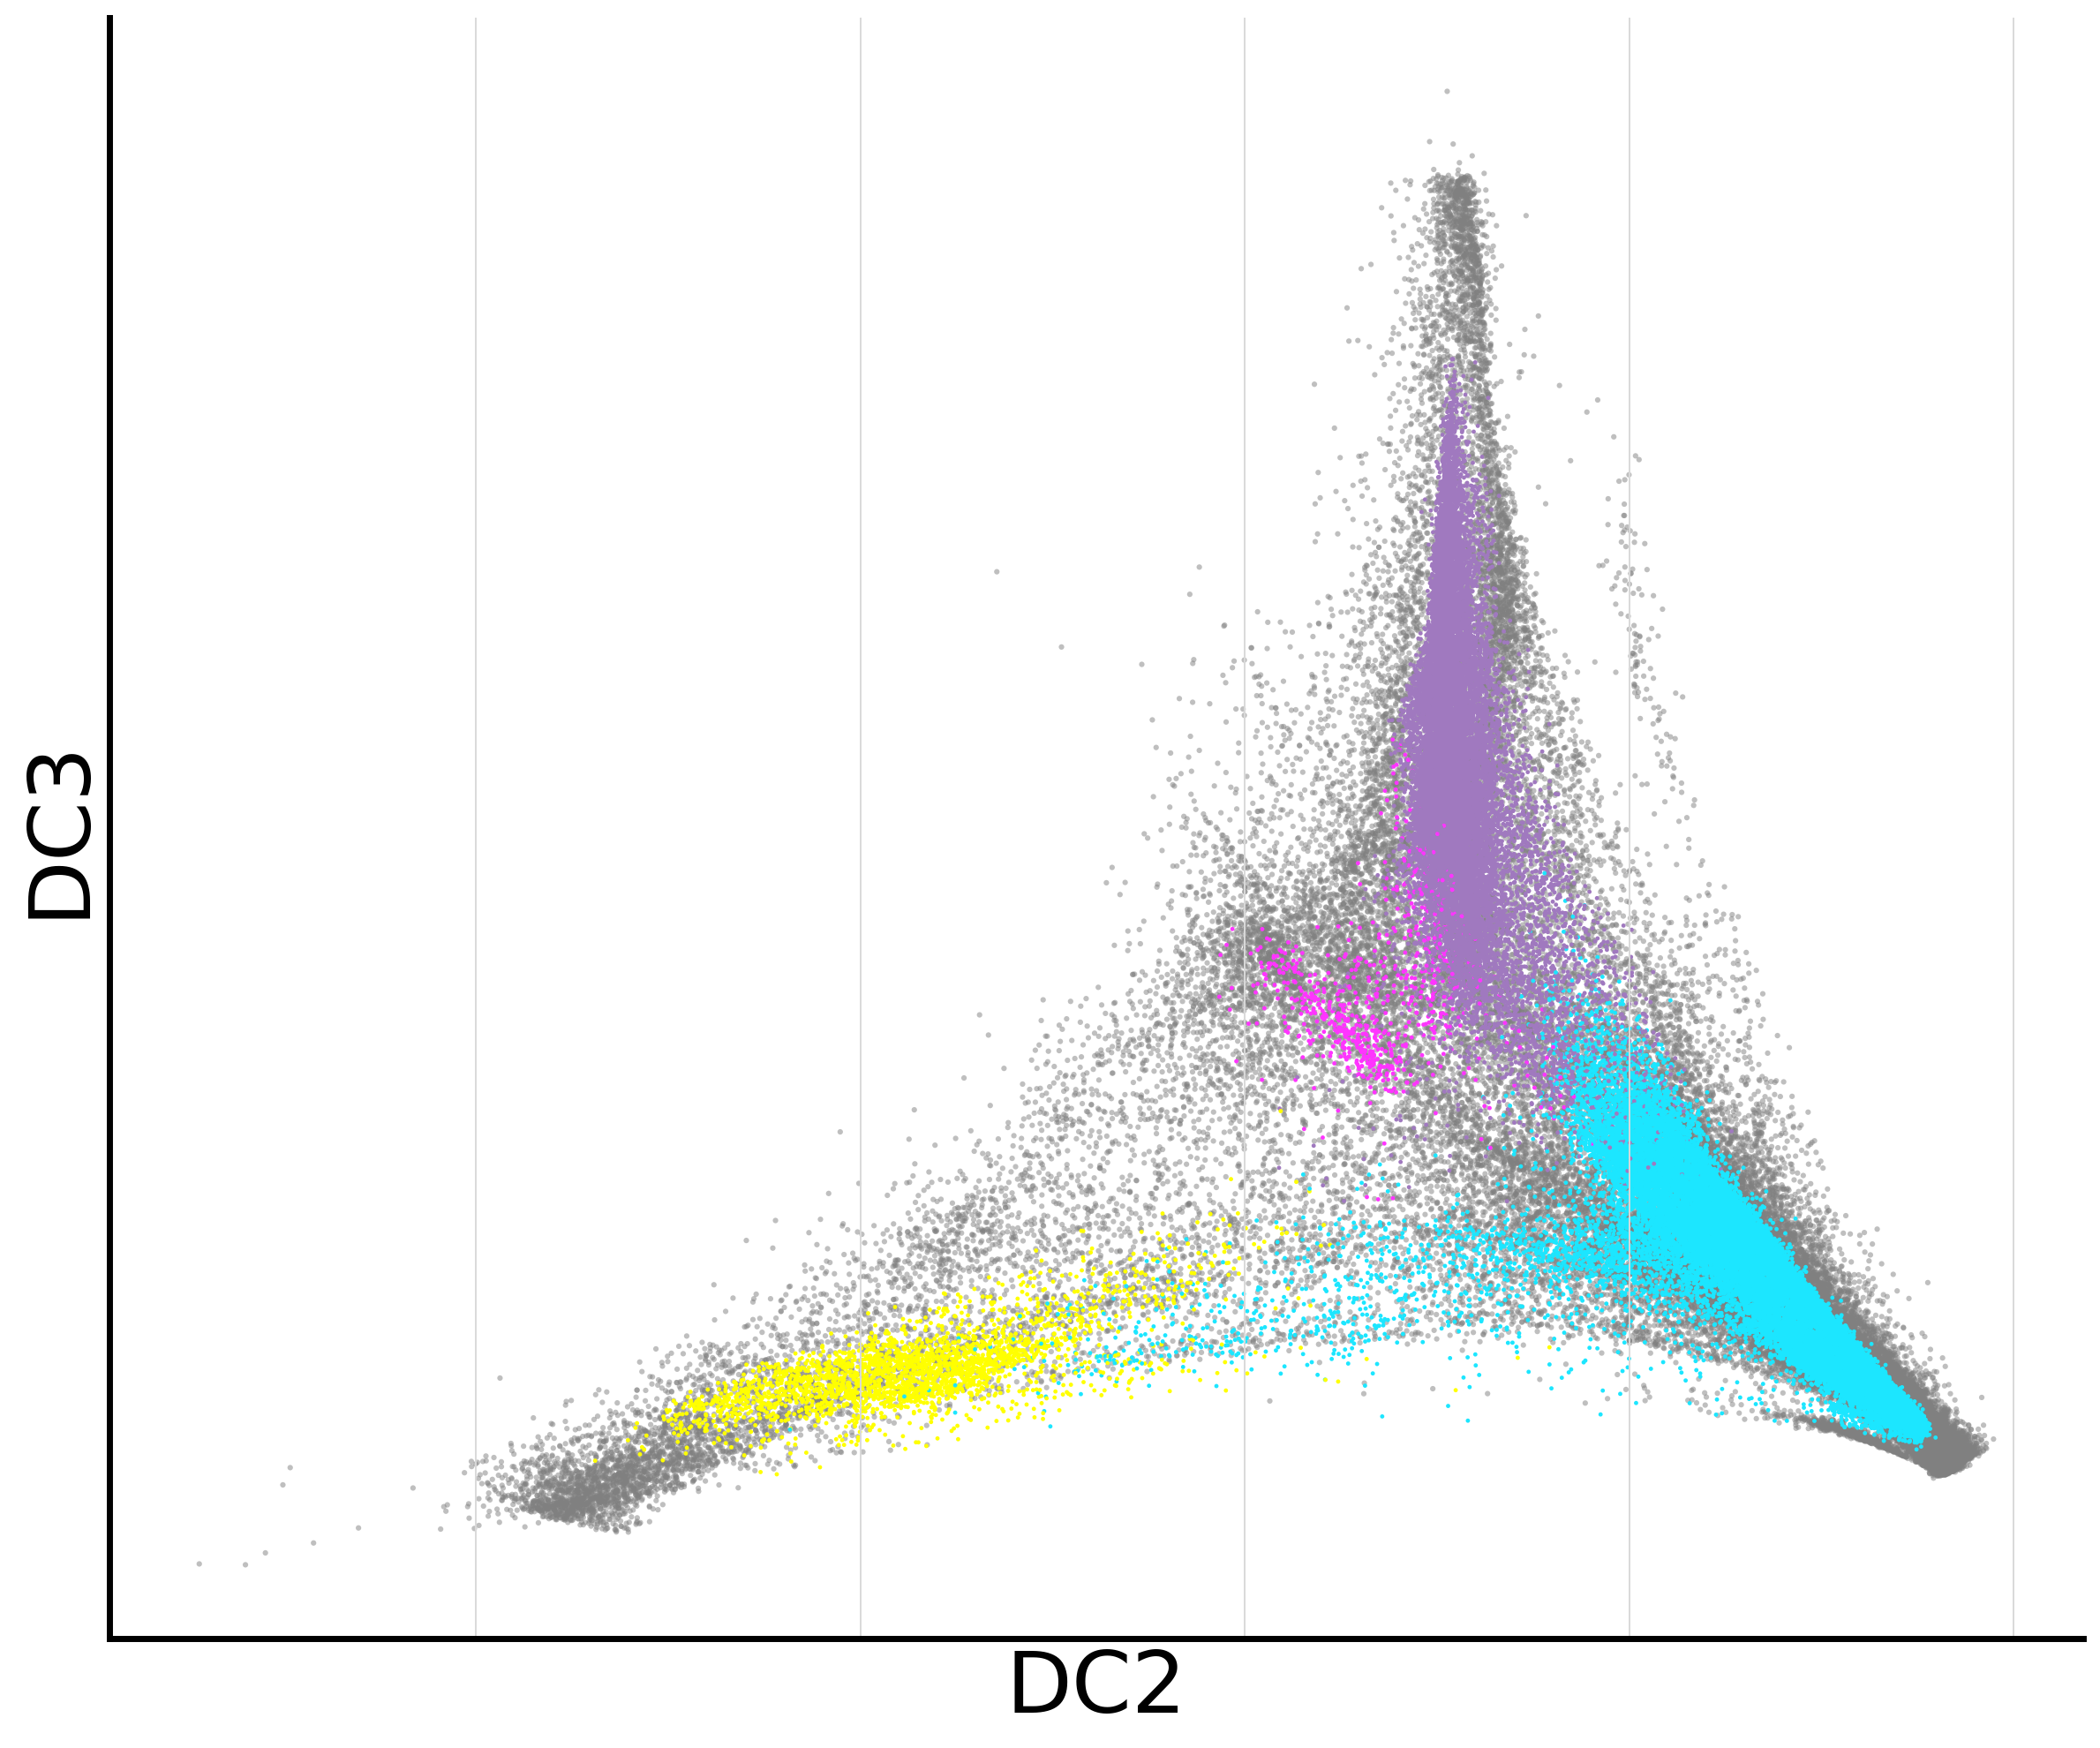

In [6]:
query30_dc23 = projected30[certain30][:, [1, 2]]
query30_labels = query30_obs.loc[
    certain30, FIGURE4A_COLOR_COLUMN
].astype(str)
query30_colors = query30_labels.map(CELL_TYPE_COLORS).fillna("#bdbdbd")

fig, ax = plt.subplots(figsize=(12, 10), dpi=200)
ax.scatter(
    atlas_dc23[:, 0], atlas_dc23[:, 1], c="#808080",
    s=5, alpha=0.5, edgecolors="none", rasterized=True,
)
ax.scatter(
    query30_dc23[:, 0], query30_dc23[:, 1], c=query30_colors,
    s=3, alpha=1.0, edgecolors="none", rasterized=True,
)
style_diffmap_axis(ax, label_size=35, spine_width=2.5)
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "Figure4A_spatial_projection.png",
    dpi=300, bbox_inches="tight", pad_inches=0.15,
)
plt.show()
plt.close(fig)

## Figure 4D — calculate the atlas AT1-to–Aberrant Basaloid pseudotime

The historical helper called this quantity `velocity_pseudotime`, but it was explicitly run with `use_velocity_graph=False`. It is therefore a diffusion/connectivity-based pseudotime rather than a velocity-vector calculation.

For reproducibility across reordered datasets, the root is selected dynamically: among the AT1 cells on the curated path, choose the cell with the minimum third diffusion coordinate. This implements the original comment, “start AT1,” without retaining the fragile historical positional index `20577`.

The compact class below preserves the transition normalization, eigendecomposition, and Scanpy DPT distance calculation used by the original PF helper. The pseudotime graph is recalculated on the curated AT1-to–Aberrant Basaloid subset, whereas DC2/DC3 displayed in the figure remain coordinates from the broader epithelial diffusion map.

In [7]:
from scanpy.tools._dpt import DPT


class HistoricalConnectivityPseudotime(DPT):
    """Minimal compatibility implementation of the manuscript PF helper."""

    def compute_transitions(self, density_normalize=True):
        connectivity = self._connectivities
        if density_normalize:
            q = np.asarray(connectivity.sum(axis=0)).ravel()
            q += q == 0
            q_matrix = (
                spdiags(1.0 / q, 0, connectivity.shape[0], connectivity.shape[0])
                if issparse(connectivity) else np.diag(1.0 / q)
            )
            kernel = q_matrix.dot(connectivity).dot(q_matrix)
        else:
            kernel = connectivity
        z = np.sqrt(np.asarray(kernel.sum(axis=0)).ravel())
        z += z == 0
        z_matrix = (
            spdiags(1.0 / z, 0, kernel.shape[0], kernel.shape[0])
            if issparse(kernel) else np.diag(1.0 / z)
        )
        self._transitions_sym = z_matrix.dot(kernel).dot(z_matrix)

    def compute_eigen(self, n_comps=10):
        n_comps = min(self._transitions_sym.shape[0] - 1, n_comps)
        eigenvalues, eigenvectors = linalg.eigsh(
            self._transitions_sym, k=n_comps, which="LM"
        )
        self._eigen_values = eigenvalues[::-1]
        self._eigen_basis = eigenvectors[:, ::-1]

    def compute_pseudotime(self):
        self._set_pseudotime()
        self.pseudotime[~np.isfinite(self.pseudotime)] = np.nan


cell_types_pt = pseudotime_atlas.obs["ct_anno"].astype(str).to_numpy()
at1_positions = np.flatnonzero(cell_types_pt == "AT1")
if not len(at1_positions):
    raise ValueError("The curated pseudotime path contains no AT1 cells.")
root_position = at1_positions[
    np.argmin(pseudotime_atlas.obsm["X_diffmap"][at1_positions, 2])
]
root_cell_name = pseudotime_atlas.obs_names[root_position]

pseudotime_model = HistoricalConnectivityPseudotime(
    pseudotime_atlas, n_dcs=10
)
pseudotime_model.compute_transitions()
pseudotime_model.compute_eigen(n_comps=10)
pseudotime_model.iroot = int(root_position)
pseudotime_model.compute_pseudotime()
pseudotime_atlas.obs["velocity_pseudotime"] = np.asarray(
    pseudotime_model.pseudotime, dtype=np.float64
)

if pseudotime_atlas.obs["velocity_pseudotime"].isna().any():
    warnings.warn(
        "Some atlas cells have non-finite pseudotime, usually because they "
        "are disconnected from the selected root."
    )

atlas_pseudotime_table = pd.DataFrame({
    "atlas_cell_id": pseudotime_atlas.obs_names.astype(str),
    "ct_anno": pseudotime_atlas.obs["ct_anno"].astype(str).to_numpy(),
    "DC2": pseudotime_atlas.obsm["X_diffmap"][:, 1],
    "DC3": pseudotime_atlas.obsm["X_diffmap"][:, 2],
    "velocity_pseudotime": pseudotime_atlas.obs["velocity_pseudotime"].to_numpy(),
    "is_root": pseudotime_atlas.obs_names.astype(str) == str(root_cell_name),
})
atlas_pseudotime_table.to_csv(
    OUTPUT_DIR / "Figure4D_atlas_pseudotime.csv.gz", index=False
)

print(f"Dynamic AT1 root: {root_cell_name} (local position {root_position})")
display(
    pseudotime_atlas.obs.groupby("ct_anno", observed=True)
    ["velocity_pseudotime"].agg(["count", "median", "min", "max"])
)

Dynamic AT1 root: dataset_9_44893 (local position 20577)


,count,median,min,max
ct_anno,,,,
AT1,18157,0.348645,0.000000,0.580134
Aberrant Basaloid,276,0.726529,0.495367,1.000000


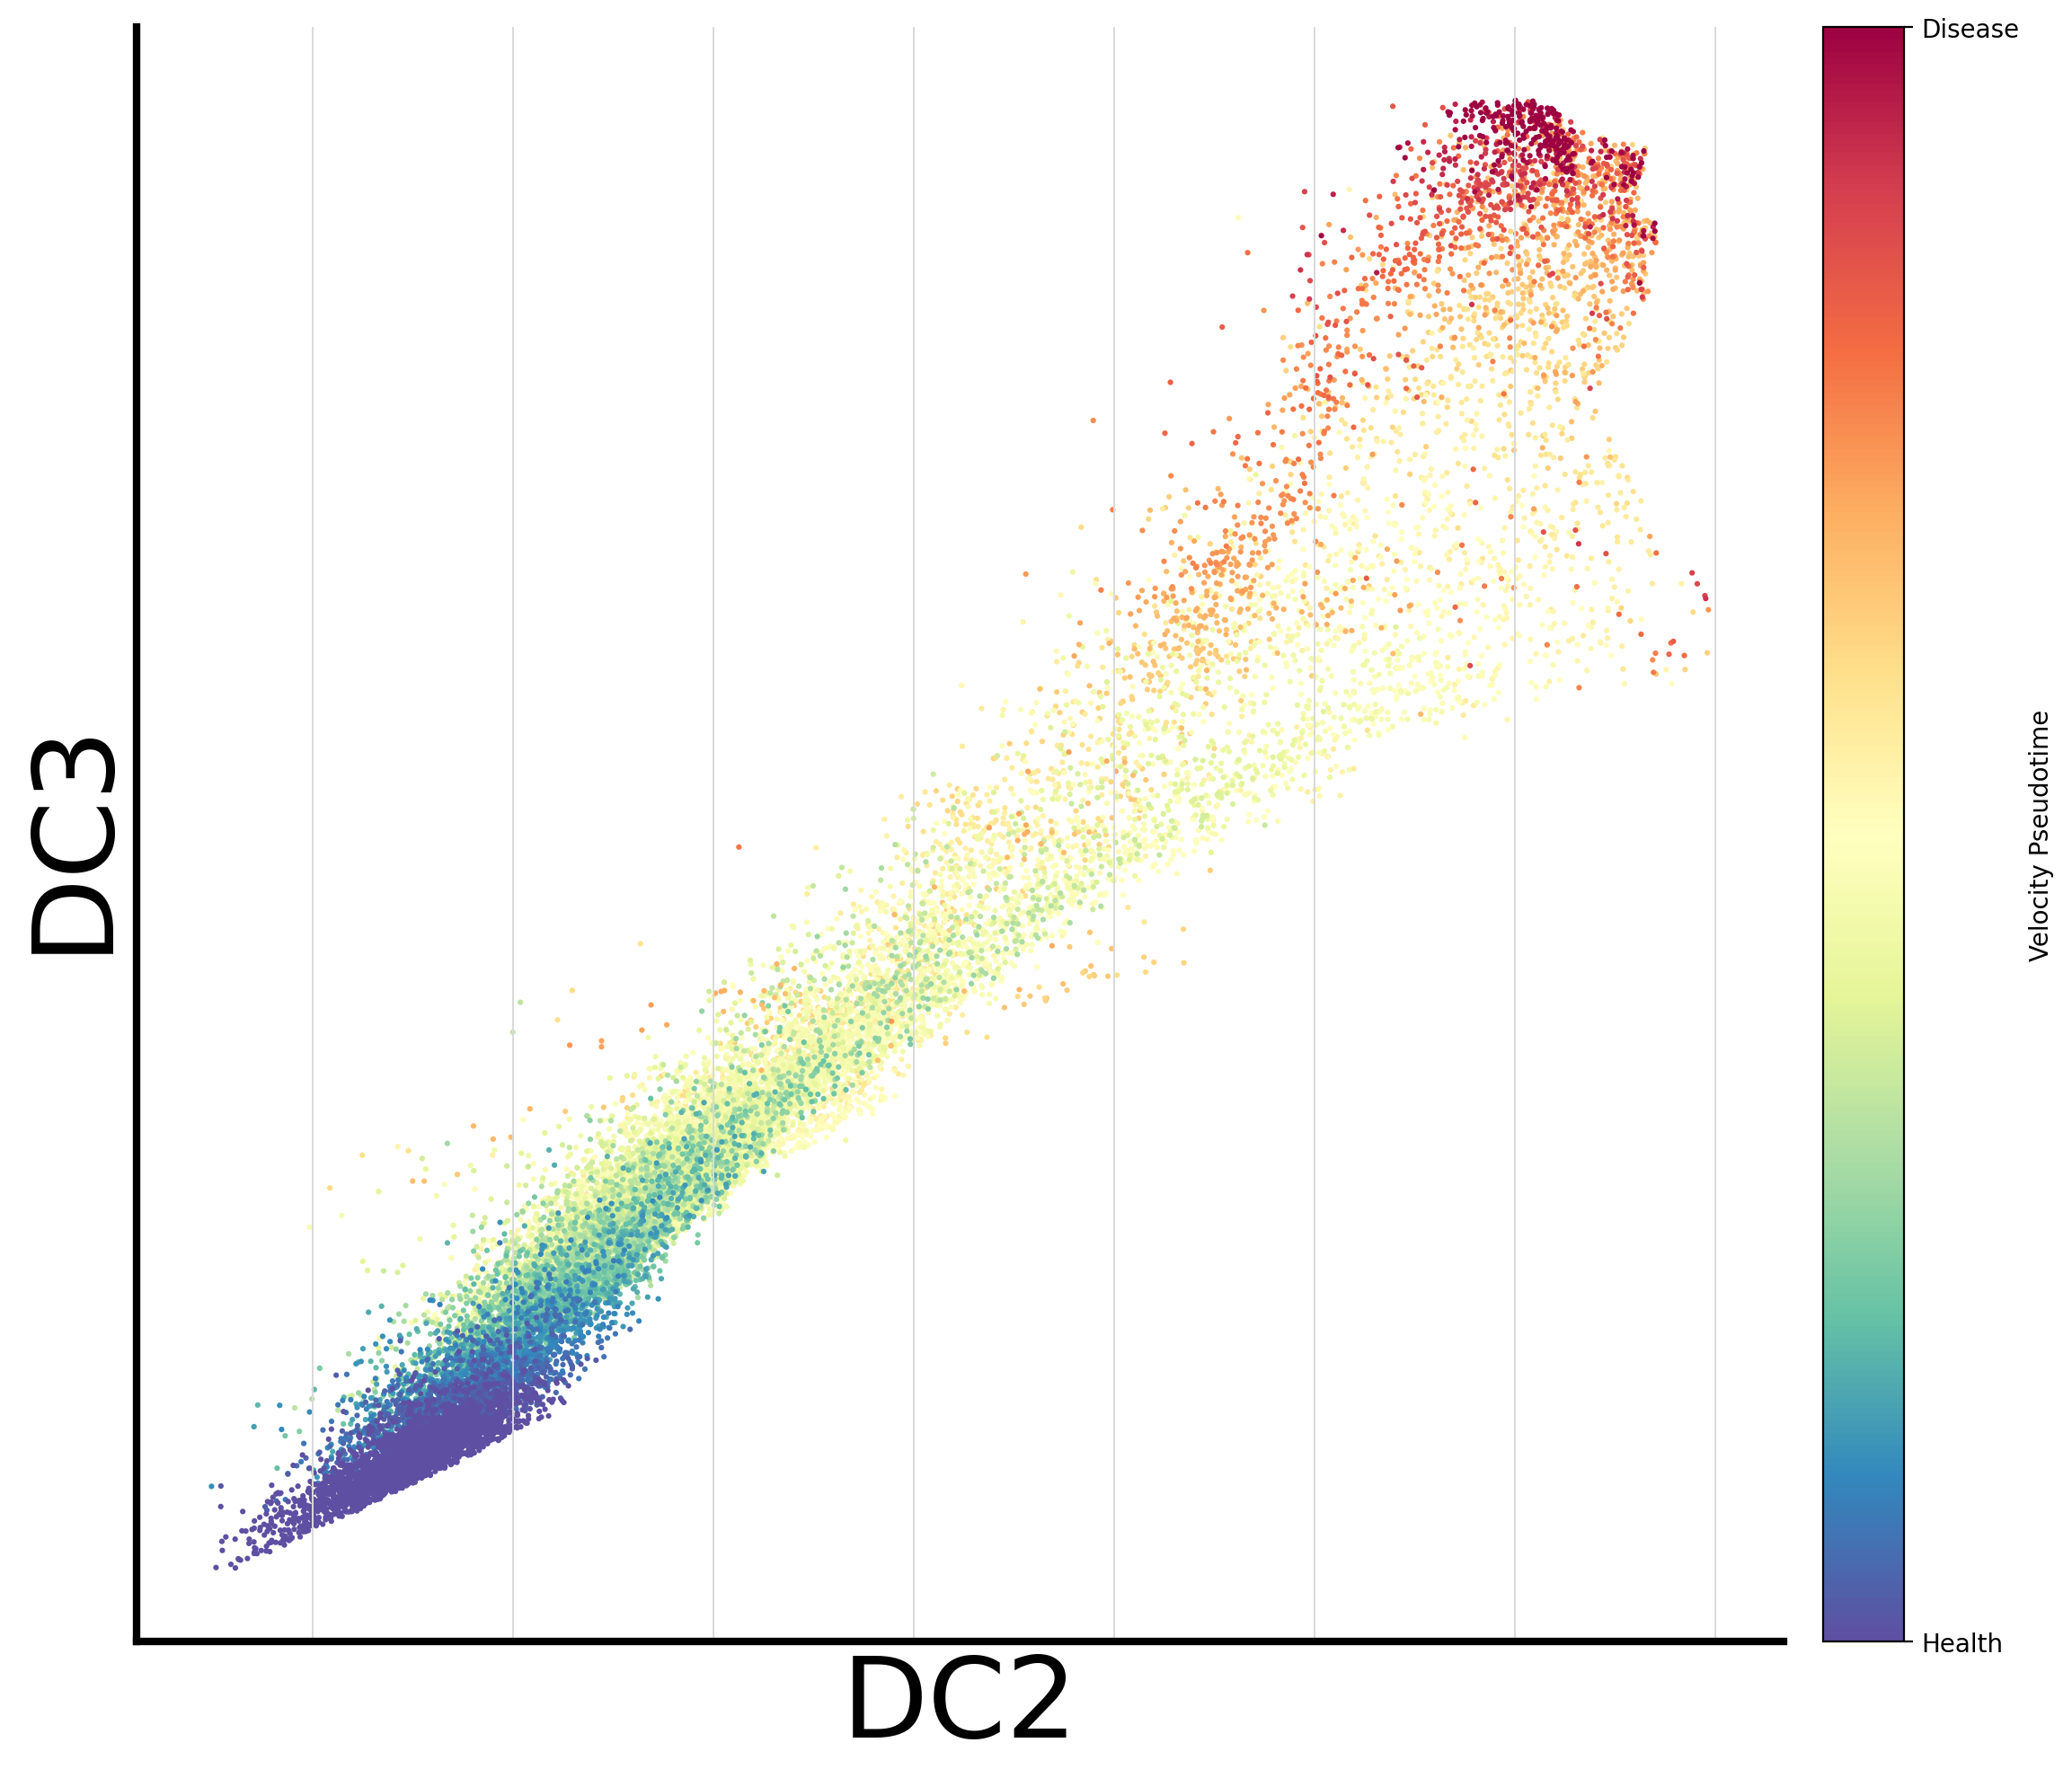

In [8]:
atlas_pt = pseudotime_atlas.obs["velocity_pseudotime"].to_numpy()
atlas_pt_dc23 = pseudotime_atlas.obsm["X_diffmap"][:, [1, 2]]
atlas_vmin = 0.1
atlas_vmax = np.nanquantile(atlas_pt, 0.99)
pseudotime_cmap = mpl.colormaps["Spectral_r"]
atlas_norm = mpl.colors.Normalize(vmin=atlas_vmin, vmax=atlas_vmax)
atlas_colors = pseudotime_cmap(atlas_norm(atlas_pt))

fig, ax = plt.subplots(figsize=(12, 10), dpi=200)
low_order = np.argsort(atlas_pt)[::-1]
low_order = low_order[atlas_pt[low_order] < 0.5]
high_order = np.argsort(atlas_pt)
high_order = high_order[atlas_pt[high_order] >= 0.5]
for order in [low_order, high_order]:
    ax.scatter(
        atlas_pt_dc23[order, 0], atlas_pt_dc23[order, 1],
        c=atlas_colors[order], s=5, alpha=1.0,
        edgecolors="none", rasterized=True,
    )
style_diffmap_axis(ax, label_size=45, spine_width=3)
colorbar = fig.colorbar(
    cm.ScalarMappable(norm=atlas_norm, cmap=pseudotime_cmap), ax=ax, pad=0.02
)
colorbar.set_label("Velocity Pseudotime")
colorbar.set_ticks([atlas_vmin, atlas_vmax])
colorbar.set_ticklabels(["Health", "Disease"])
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "Figure4D_atlas_pseudotime.png",
    dpi=300, bbox_inches="tight", pad_inches=0.15,
)
plt.show()
plt.close(fig)

## Figure 4D — transfer atlas pseudotime to spatial cells

Pseudotime transfer uses the 300-neighbor rerun. Two related normalizations are deliberately kept separate, matching the original notebook:

- **Pseudotime:** restrict the query connectivity matrix to the curated pseudotime path and then row-normalize. The spatial value is the weighted mean of atlas pseudotime along that path.
- **Displayed DC coordinates:** row-normalize over the complete mapped epithelial atlas first, and then use the path columns to project atlas DC coordinates.

Spatial cells are retained when their unnormalized connectivity mass to the curated path is greater than 4. The resulting `spatial_pseudotime.csv.gz` is the complete handoff to notebook 05: it contains stable query identifiers, sample and spatial coordinates, newly mapped cell type and probability, connectivity mass, transferred pseudotime, and projected DC2/DC3.

In [9]:
del mapping30
gc.collect()

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore", message="Observation names are not unique.*",
        category=UserWarning,
    )
    mapping300 = load_mapping_result(
        MAPPING_300_PATH, expected_neighbors=300
    )
query300_obs, parameters300 = prepare_query_metadata(
    mapping300, MAPPING_300_PATH
)
if not np.array_equal(
    query30_obs["query_id"].to_numpy(),
    query300_obs["query_id"].to_numpy(),
):
    raise ValueError("30- and 300-neighbor mapping rows are not aligned.")

pseudotime_coordinates = pd.DataFrame(
    pseudotime_atlas.obsm["X_diffmap"],
    index=pseudotime_atlas.obs_names,
)
projected300, trajectory_mass300 = project_query_to_atlas(
    mapping300, pseudotime_coordinates, normalize_by="all"
)
spatial_pseudotime_all, pseudotime_mass300 = project_query_to_atlas(
    mapping300,
    pseudotime_atlas.obs["velocity_pseudotime"],
    normalize_by="subset",
)
np.testing.assert_allclose(pseudotime_mass300, trajectory_mass300)
spatial_pseudotime_all[trajectory_mass300 == 0] = np.nan
certain300 = trajectory_mass300 > TRAJECTORY_MASS_CUTOFF

output_columns = [
    "query_id", "sample", "cell_id", "x_centroid", "y_centroid",
    FIGURE4A_COLOR_COLUMN, LABEL_COLUMN, PROBABILITY_COLUMN,
]
spatial_pseudotime = query300_obs.loc[certain300, output_columns].copy()
spatial_pseudotime["trajectory_connectivity_mass"] = (
    trajectory_mass300[certain300]
)
spatial_pseudotime["spatial_pseudotime"] = (
    spatial_pseudotime_all[certain300]
)
spatial_pseudotime["projected_DC2"] = projected300[certain300, 1]
spatial_pseudotime["projected_DC3"] = projected300[certain300, 2]
spatial_pseudotime.to_csv(SPATIAL_PSEUDOTIME_OUTPUT, index=False)
print(f"Saved notebook 05 handoff: {SPATIAL_PSEUDOTIME_OUTPUT}")

sample_summary = (
    spatial_pseudotime.groupby("sample", observed=True)
    .agg(
        n_cells=("query_id", "size"),
        median_pseudotime=("spatial_pseudotime", "median"),
        min_pseudotime=("spatial_pseudotime", "min"),
        max_pseudotime=("spatial_pseudotime", "max"),
    )
    .reset_index()
)
sample_summary.to_csv(
    OUTPUT_DIR / "Figure4D_spatial_pseudotime_by_sample.tsv",
    sep="\t", index=False,
)

print(f"300-neighbor query cells: {len(query300_obs):,}")
print(
    f"Cells with trajectory connectivity mass > {TRAJECTORY_MASS_CUTOFF:g}: "
    f"{certain300.sum():,} ({certain300.mean():.1%})"
)
print(
    "Transferred pseudotime range: "
    f"{spatial_pseudotime['spatial_pseudotime'].min():.4f}–"
    f"{spatial_pseudotime['spatial_pseudotime'].max():.4f}"
)
display(sample_summary)

300-neighbor query cells: 128,353
Cells with trajectory connectivity mass > 4: 22,854 (17.8%)
Transferred pseudotime range: 0.0569–0.8442


,sample,n_cells,median_pseudotime,min_pseudotime,max_pseudotime
0,VUILD48LA1,1017,0.536902,0.171594,0.775548
1,VUILD48LA2,1111,0.482959,0.205324,0.768978
2,VUILD49LA,1255,0.495277,0.205550,0.768808
3,VUILD58MA,625,0.543702,0.120351,0.823265
4,VUILD78LA,1740,0.577750,0.268661,0.805088
5,VUILD78MA,1338,0.560910,0.109733,0.832938
6,VUILD91LA,1312,0.459136,0.221464,0.814407
7,VUILD91MA,581,0.566526,0.272465,0.811551
8,VUILD96LA,1872,0.469544,0.242675,0.753207
9,VUILD96MA,38,0.523156,0.299850,0.801138


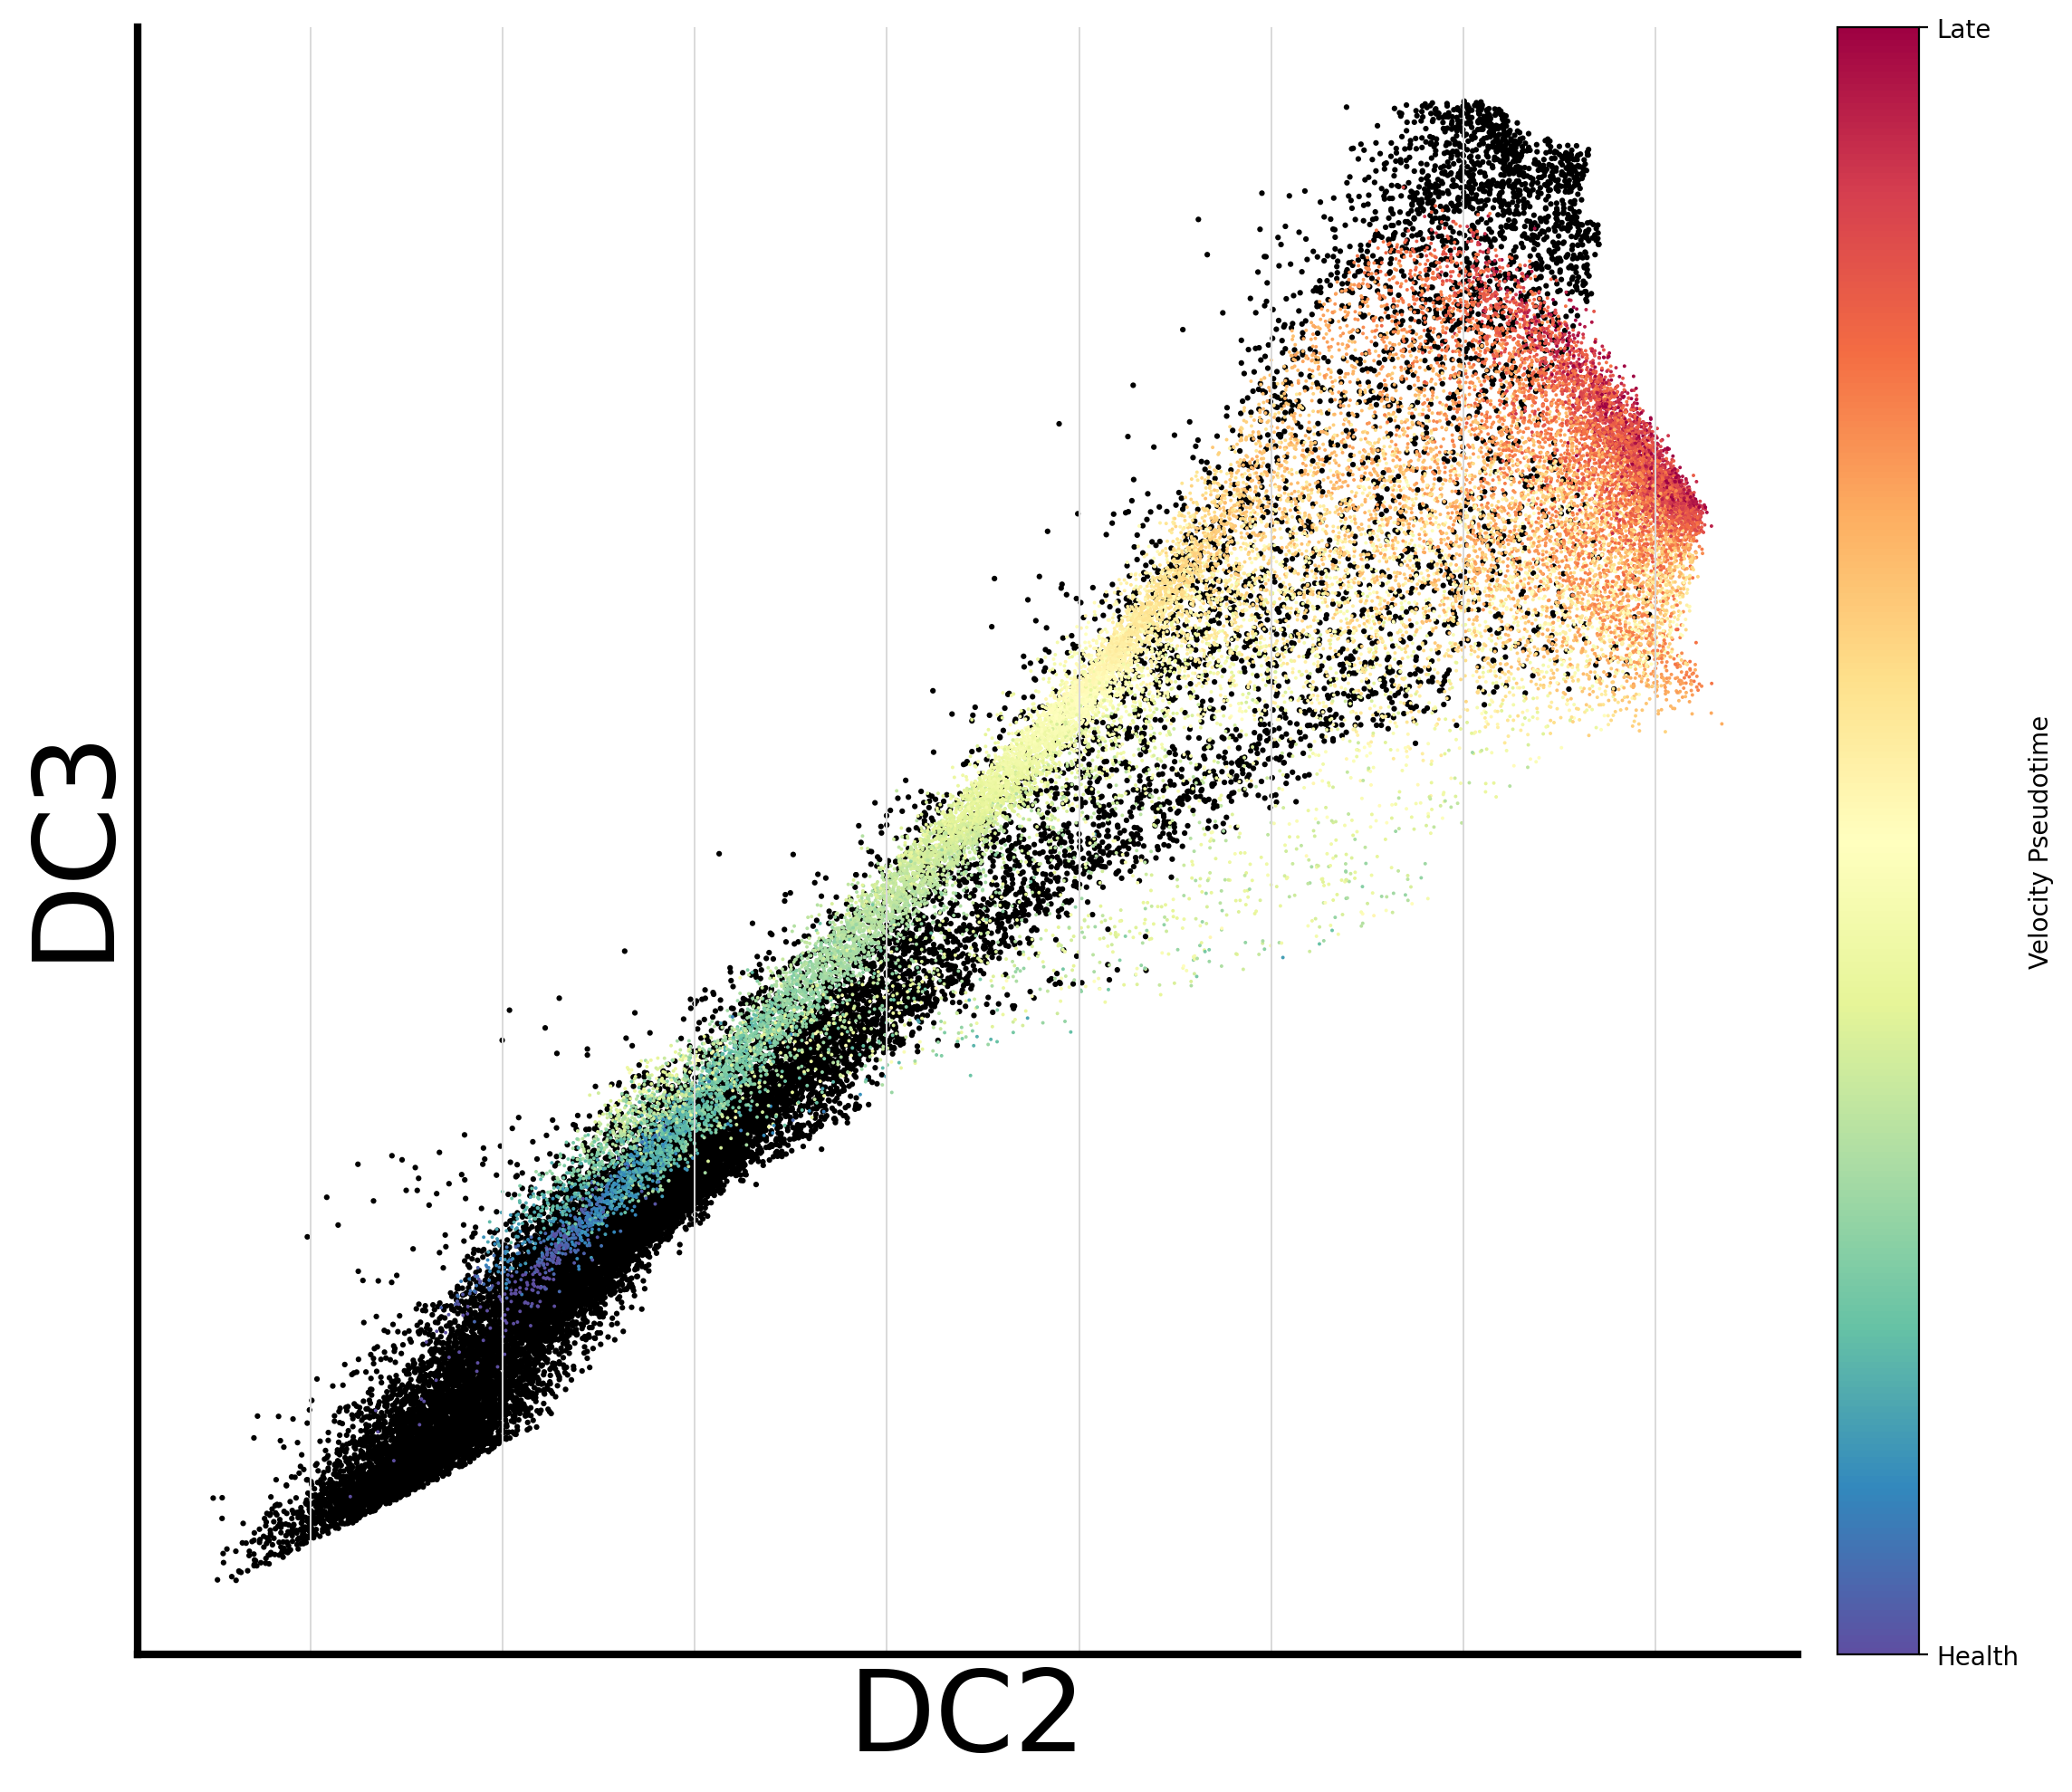

Saved Figure 4A/4D outputs to UniGeneX/Real_data_PF/outputs/04_epithelial_trajectory_and_spatial_pseudotime


In [10]:
spatial_pt_values = spatial_pseudotime_all[certain300]
spatial_pt_dc23 = projected300[certain300][:, [1, 2]]
spatial_vmin = 0.25
spatial_vmax = np.nanquantile(spatial_pt_values, 0.99)
spatial_norm = mpl.colors.Normalize(vmin=spatial_vmin, vmax=spatial_vmax)
spatial_colors = pseudotime_cmap(spatial_norm(spatial_pt_values))

fig, ax = plt.subplots(figsize=(12, 10), dpi=200)
ax.scatter(
    atlas_pt_dc23[:, 0], atlas_pt_dc23[:, 1],
    c="black", s=5, alpha=1.0, edgecolors="none", rasterized=True,
)
ax.scatter(
    spatial_pt_dc23[:, 0], spatial_pt_dc23[:, 1],
    c=spatial_colors, s=2, alpha=1.0, edgecolors="none", rasterized=True,
)
style_diffmap_axis(ax, label_size=45, spine_width=3)
colorbar = fig.colorbar(
    cm.ScalarMappable(norm=spatial_norm, cmap=pseudotime_cmap),
    ax=ax, pad=0.02,
)
colorbar.set_label("Velocity Pseudotime")
colorbar.set_ticks([spatial_vmin, spatial_vmax])
colorbar.set_ticklabels(["Health", "Late"])
fig.tight_layout()
fig.savefig(
    OUTPUT_DIR / "Figure4D_spatial_pseudotime.png",
    dpi=300, bbox_inches="tight", pad_inches=0.15,
)
plt.show()
plt.close(fig)

run_summary = pd.DataFrame([
    {"quantity": "diffusion_map_atlas_cells", "value": trajectory_atlas.n_obs},
    {"quantity": "figure4a_atlas_cells", "value": figure4a_atlas.n_obs},
    {"quantity": "pseudotime_atlas_cells", "value": pseudotime_atlas.n_obs},
    {"quantity": "figure4a_retained_query_cells", "value": int(certain30.sum())},
    {"quantity": "figure4d_retained_query_cells", "value": int(certain300.sum())},
    {"quantity": "trajectory_mass_cutoff", "value": TRAJECTORY_MASS_CUTOFF},
    {"quantity": "dynamic_AT1_root", "value": str(root_cell_name)},
])
run_summary.to_csv(OUTPUT_DIR / "run_summary.tsv", sep="\t", index=False)

del mapping300
gc.collect()
print(f"Saved Figure 4A/4D outputs to {OUTPUT_DIR}")

## Interpretation and handoff to Figure 4E

Figure 4A evaluates whether spatial epithelial cells occupy the same atlas trajectory geometry as the single-cell reference. Figure 4D then expresses position along the curated AT1-to–Aberrant Basaloid path as a continuous value and transfers it through the query-to-atlas connectivity weights. These are mapping-derived quantities; they do not use tissue coordinates when calculating pseudotime.

The next notebook will use only `spatial_pseudotime.csv.gz`, the registered `VUILD106MA` H&E image, and `Xenium_sf.npy`. Keeping the histology overlay separate makes Figures 4A/4D reproducible without loading the large TIFF and makes the exact numerical handoff auditable.